# H2 — Reducción y cambio en el patrón de precipitaciones

Analizamos si ha habido una reducción en la precipitación total anual, un aumento de episodios de lluvia intensa, y un incremento de las rachas secas en Euskal Herria entre 1940 y 2025.

## 1. Imports y carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.variables import CIUDADES, crear_dirs
from scripts.funciones_variables import cargar_datos
from scripts.analisis import precipitaciones, racha_seca
from scripts.graficos import graficos_precip, graficos_racha_seca

crear_dirs()
cargar_datos()

📂 Cargando datos...
  ✅ bilbo: 31,412 filas
  ✅ donostia: 31,412 filas
  ✅ gasteiz: 31,412 filas
  ✅ iruna: 31,412 filas
  ✅ baiona: 31,412 filas
  ✅ arrasate: 31,412 filas
  ✅ maule: 31,412 filas



## 2. Precipitación total anual

Precipitación acumulada por año. Azul intenso (≥1400 mm) → año muy lluvioso. Azul claro (1000–1399 mm) → año normal. Rosa/rojo (<1000 mm) → año seco. Se anotan los años por debajo de 800 mm.

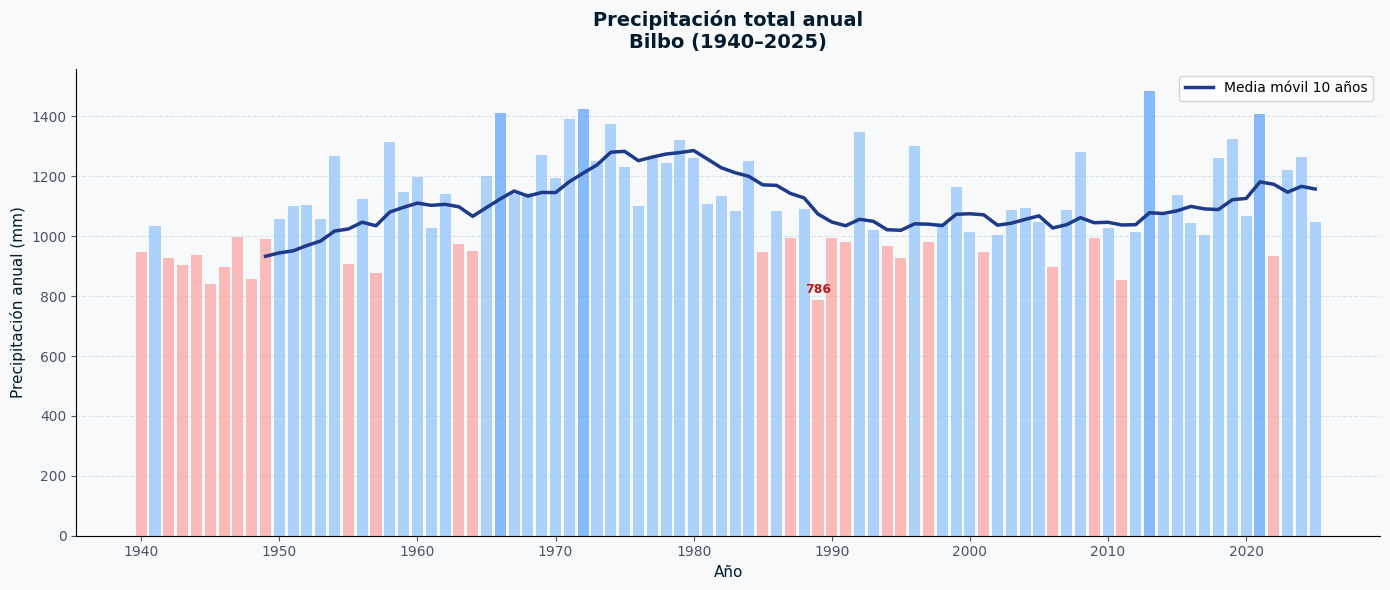

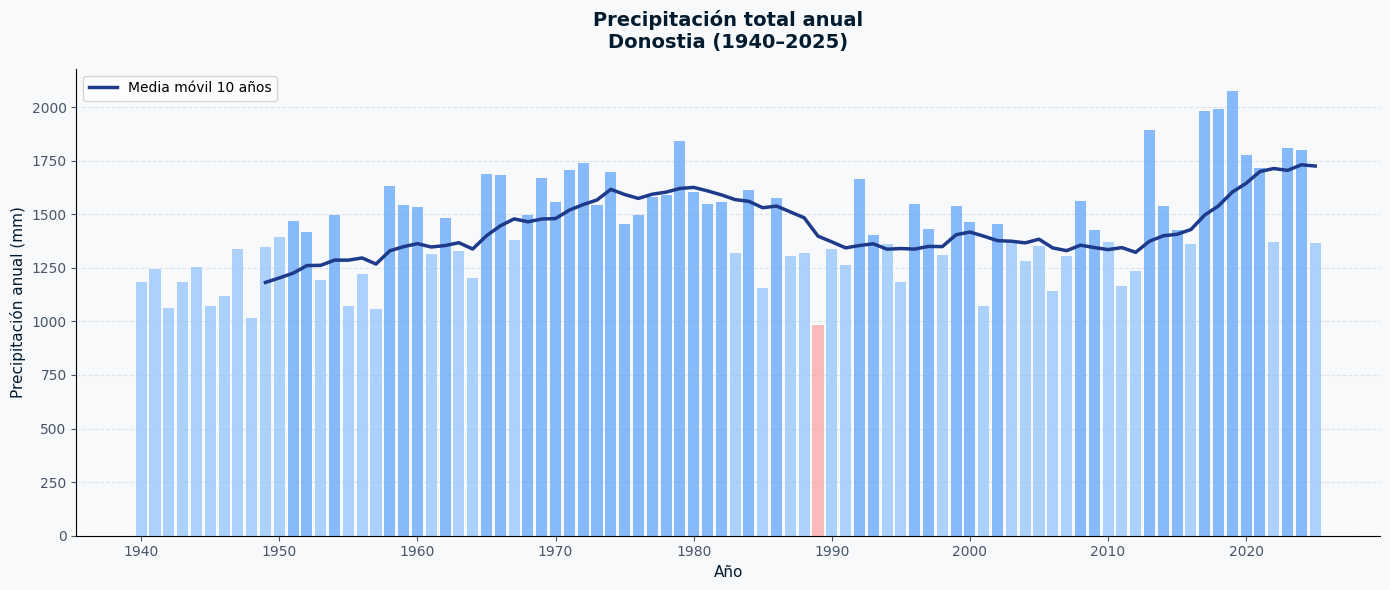

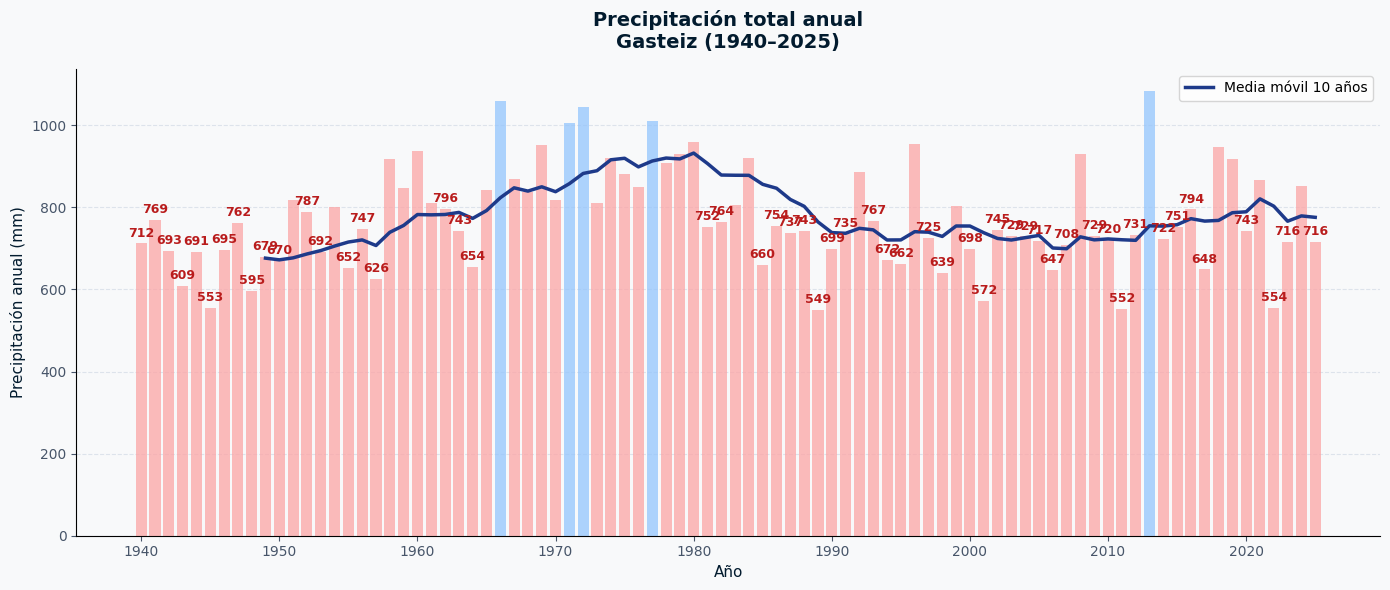

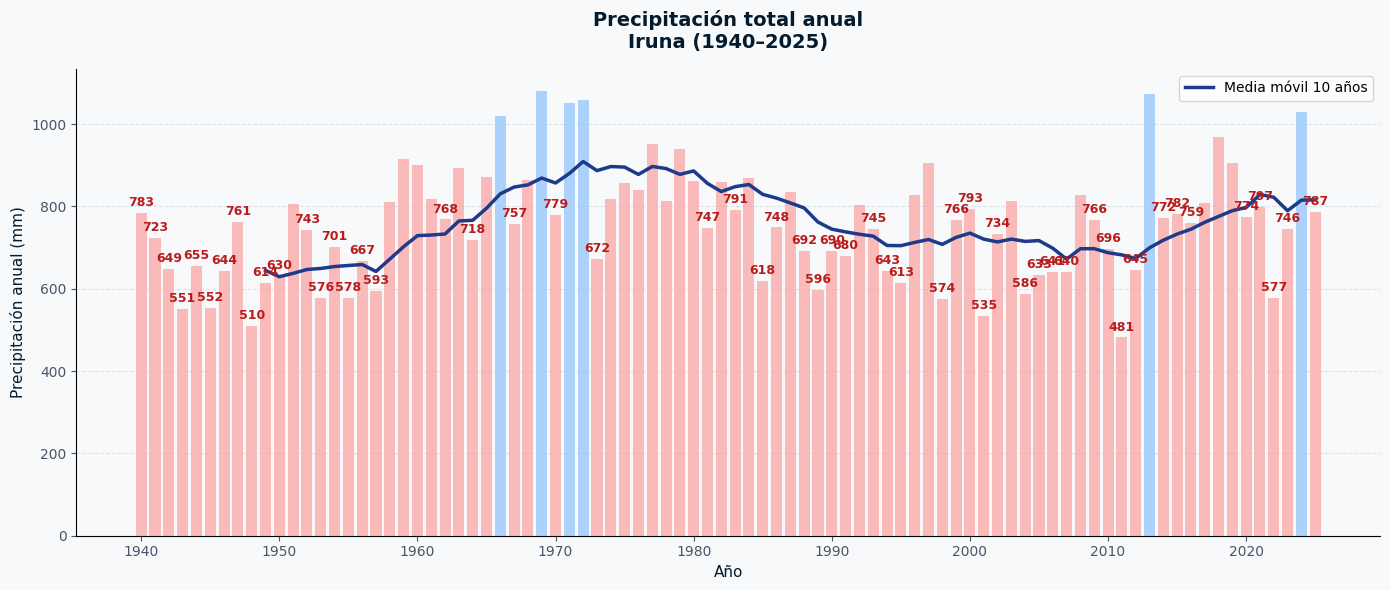

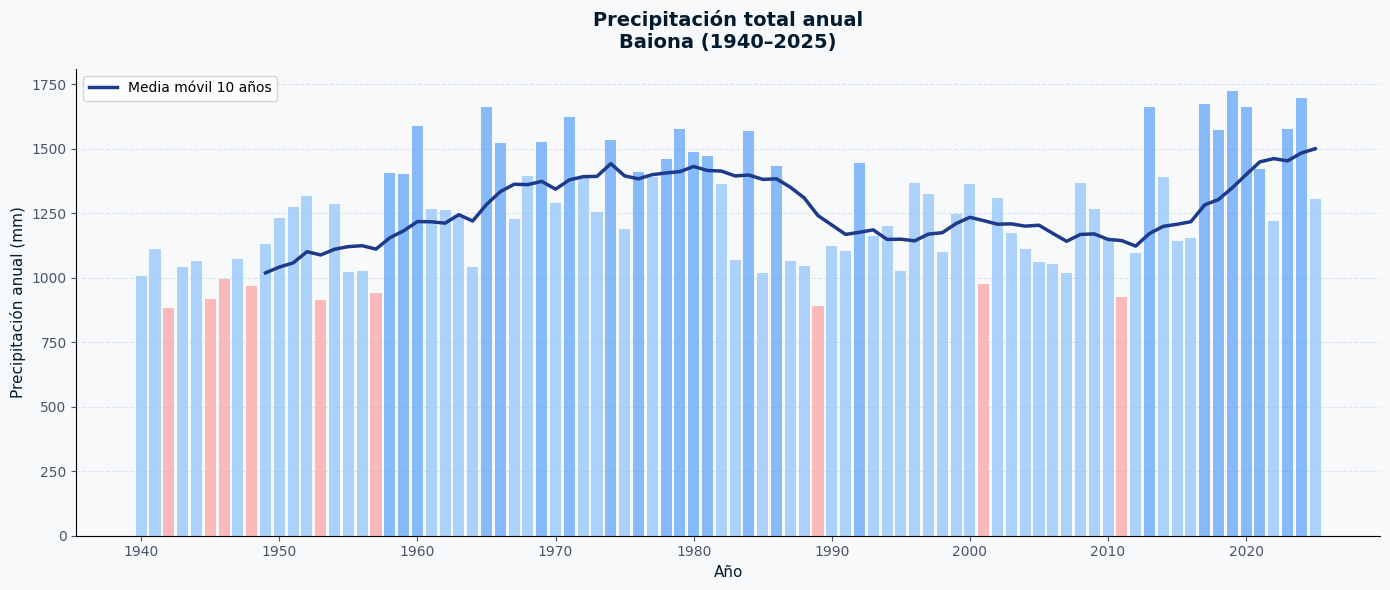

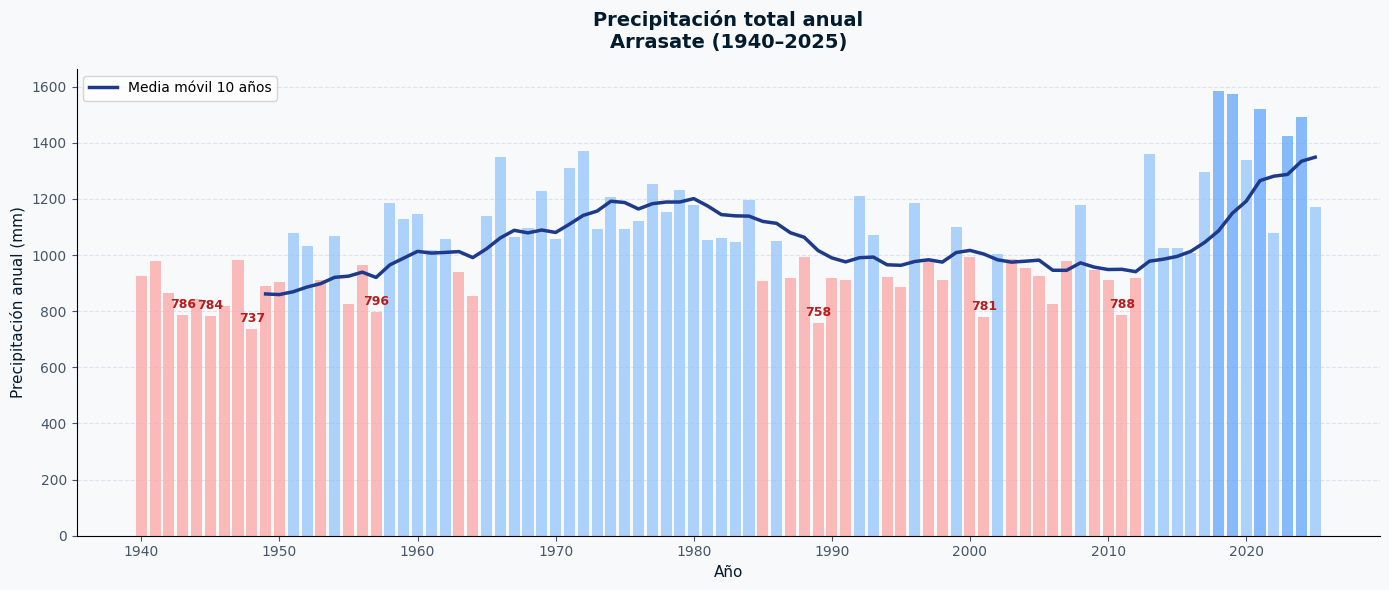

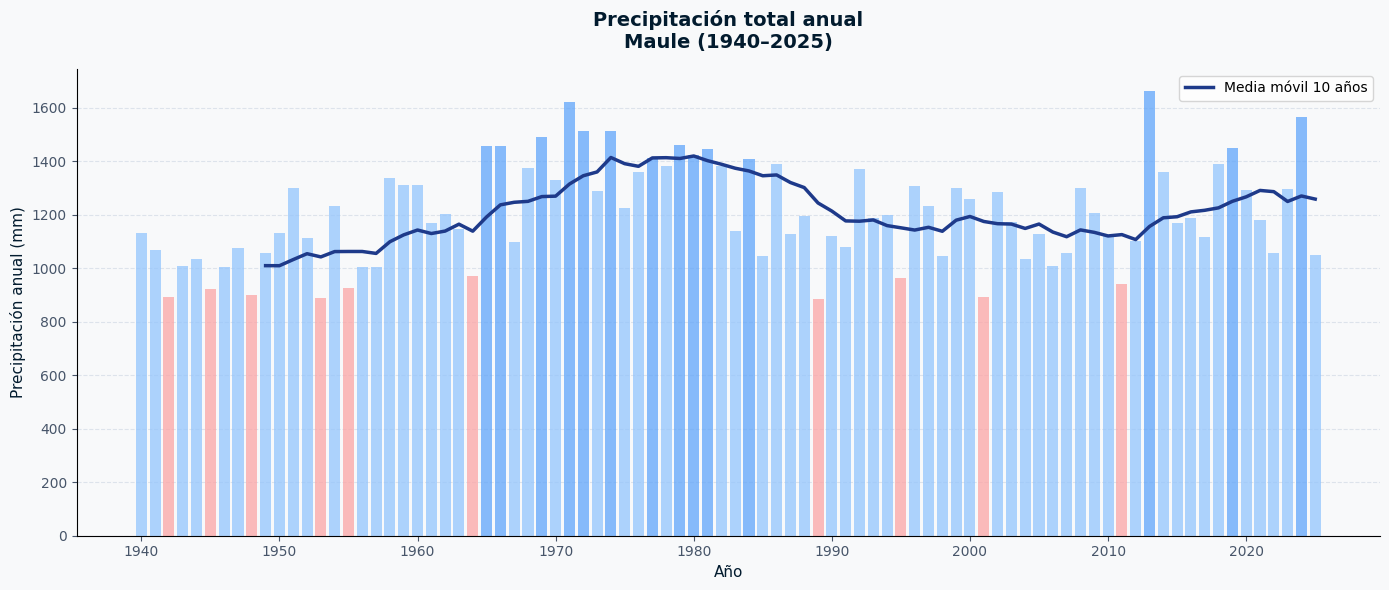

In [2]:
datos_precip = precipitaciones.calcular_todos()
graficos_precip.graficar_precipitacion_anual(datos_precip['precip_anual'])

## 3. Días con precipitación intensa (> 30 mm)

Contamos los días al año con precipitación superior a 30 mm. Un aumento aquí, combinado con descenso del total anual, indicaría que llueve lo mismo pero más concentrado y con más sequías intermedias.

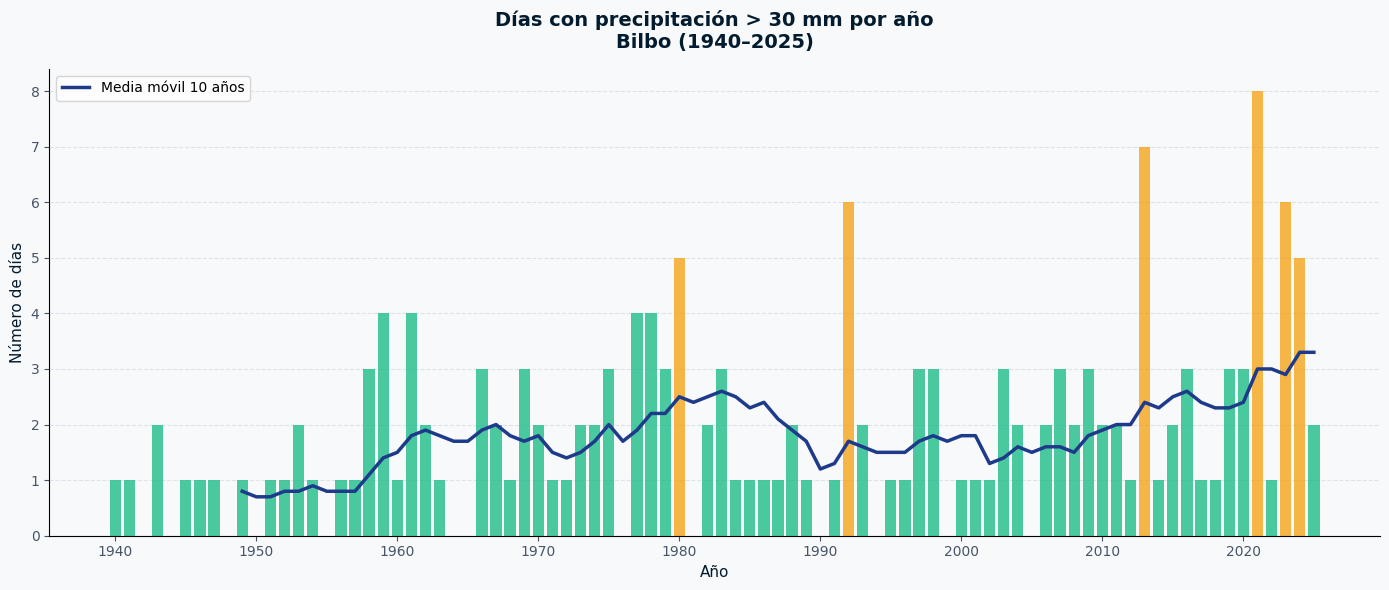

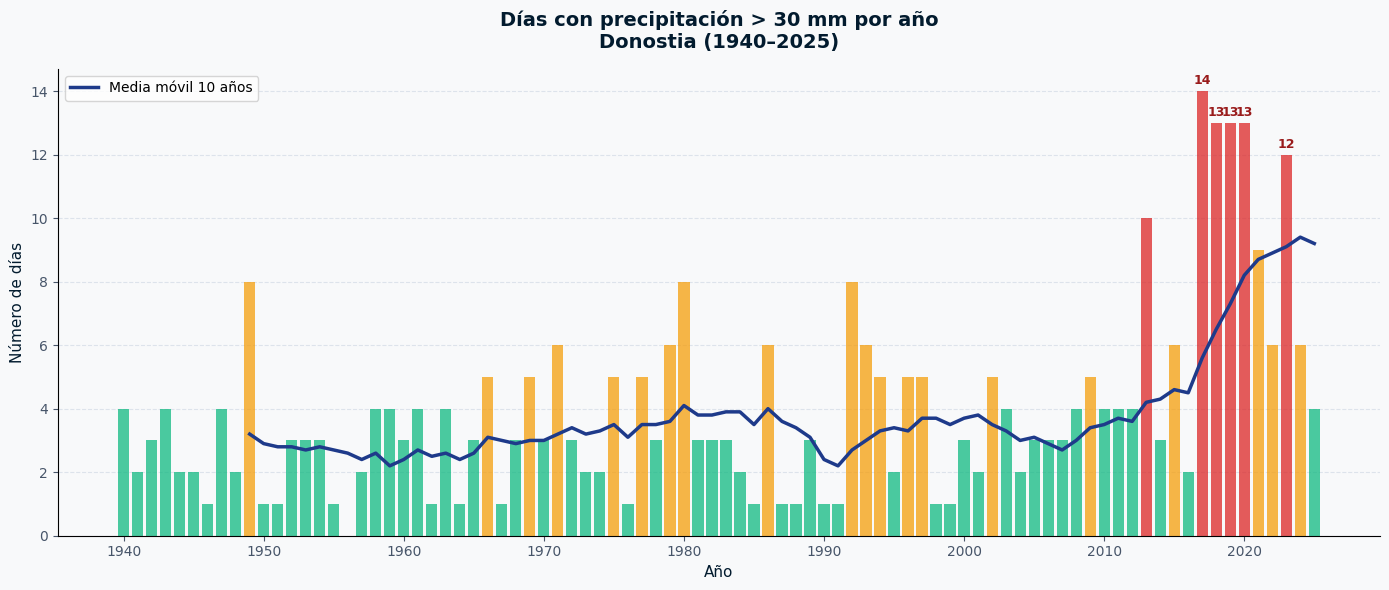

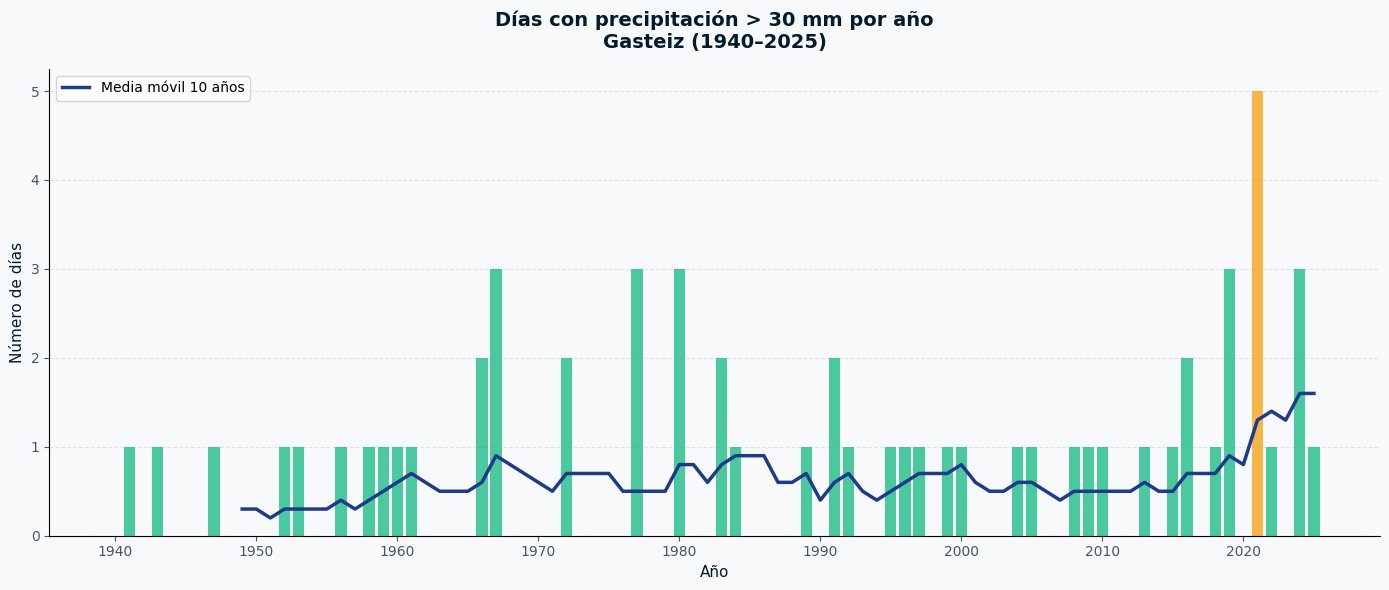

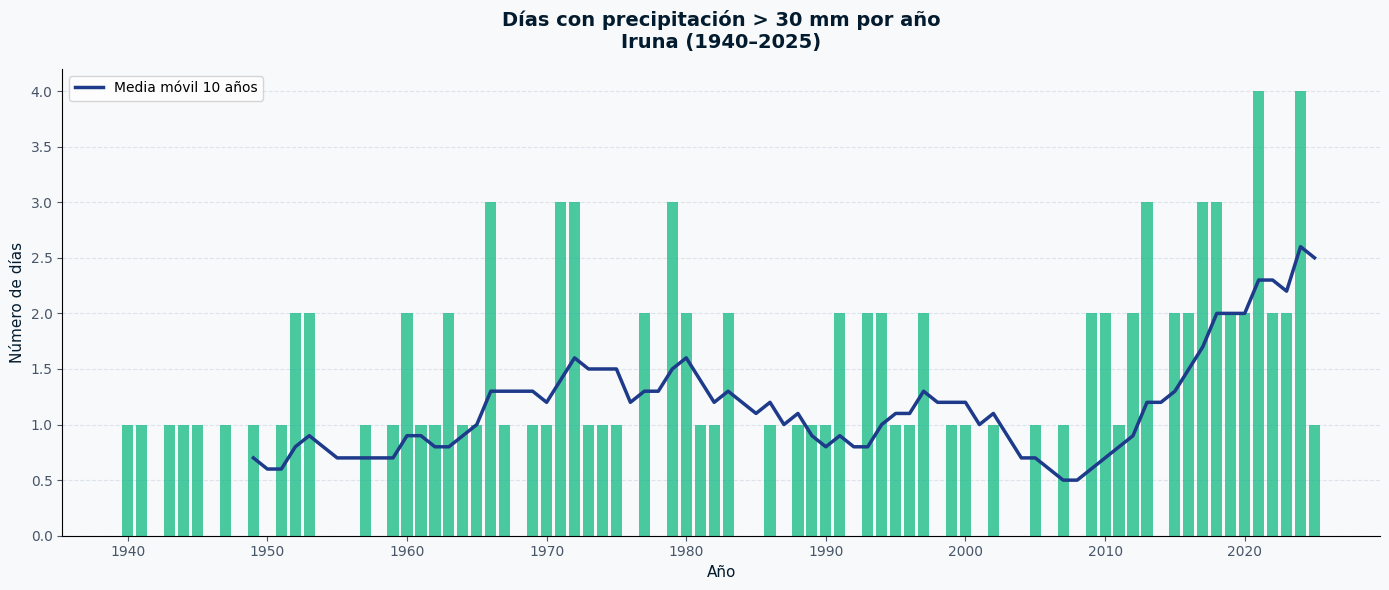

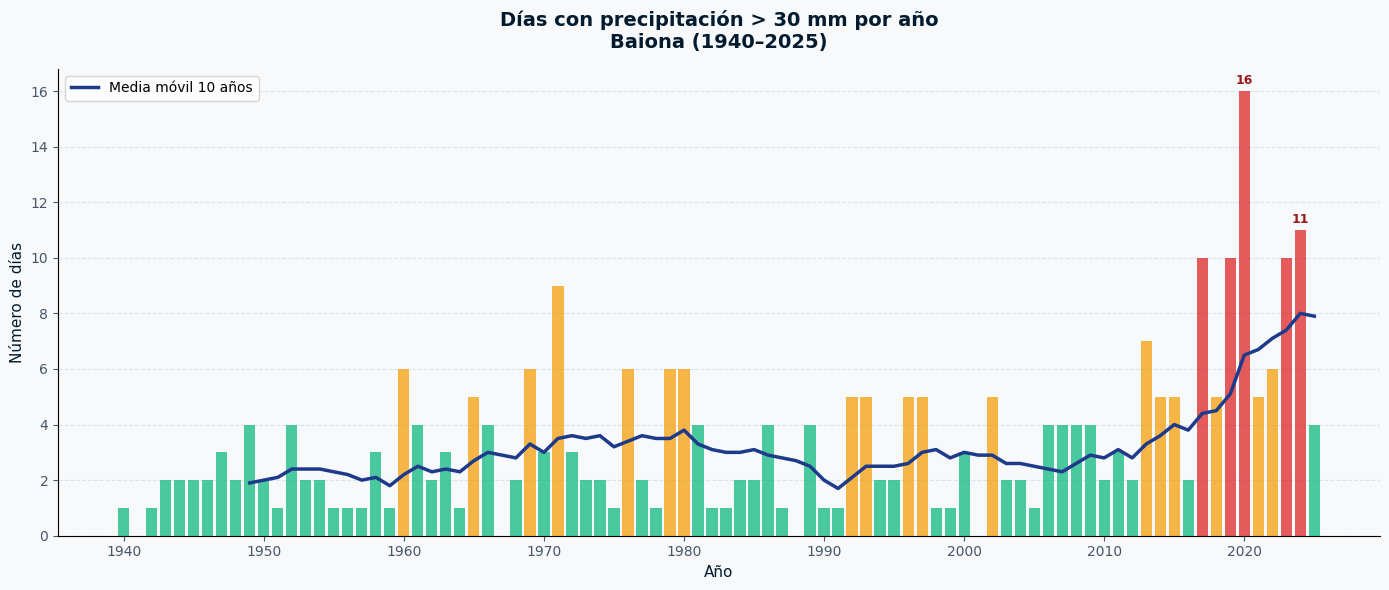

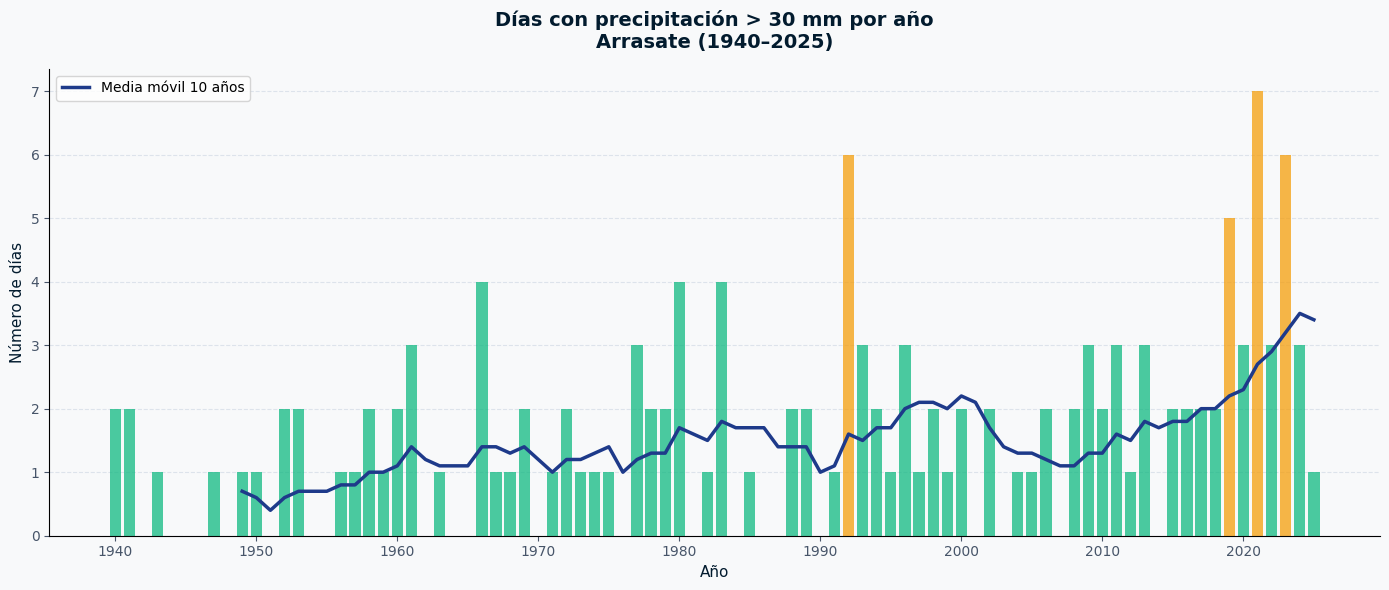

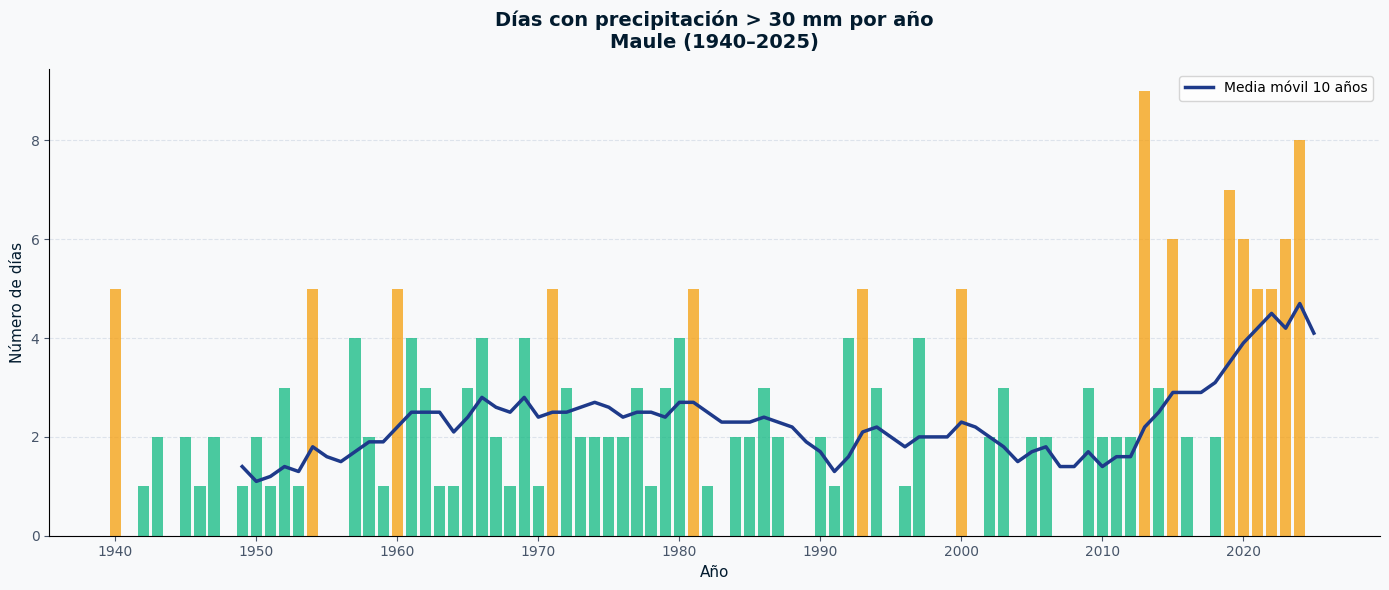

In [3]:
graficos_precip.graficar_dias_intensos(datos_precip['dias_intensos'])

## 4. Heatmap de precipitación mensual

Matriz año × mes de la precipitación total mensual. Permite detectar si hay meses que se están secando sistemáticamente a lo largo de las décadas.

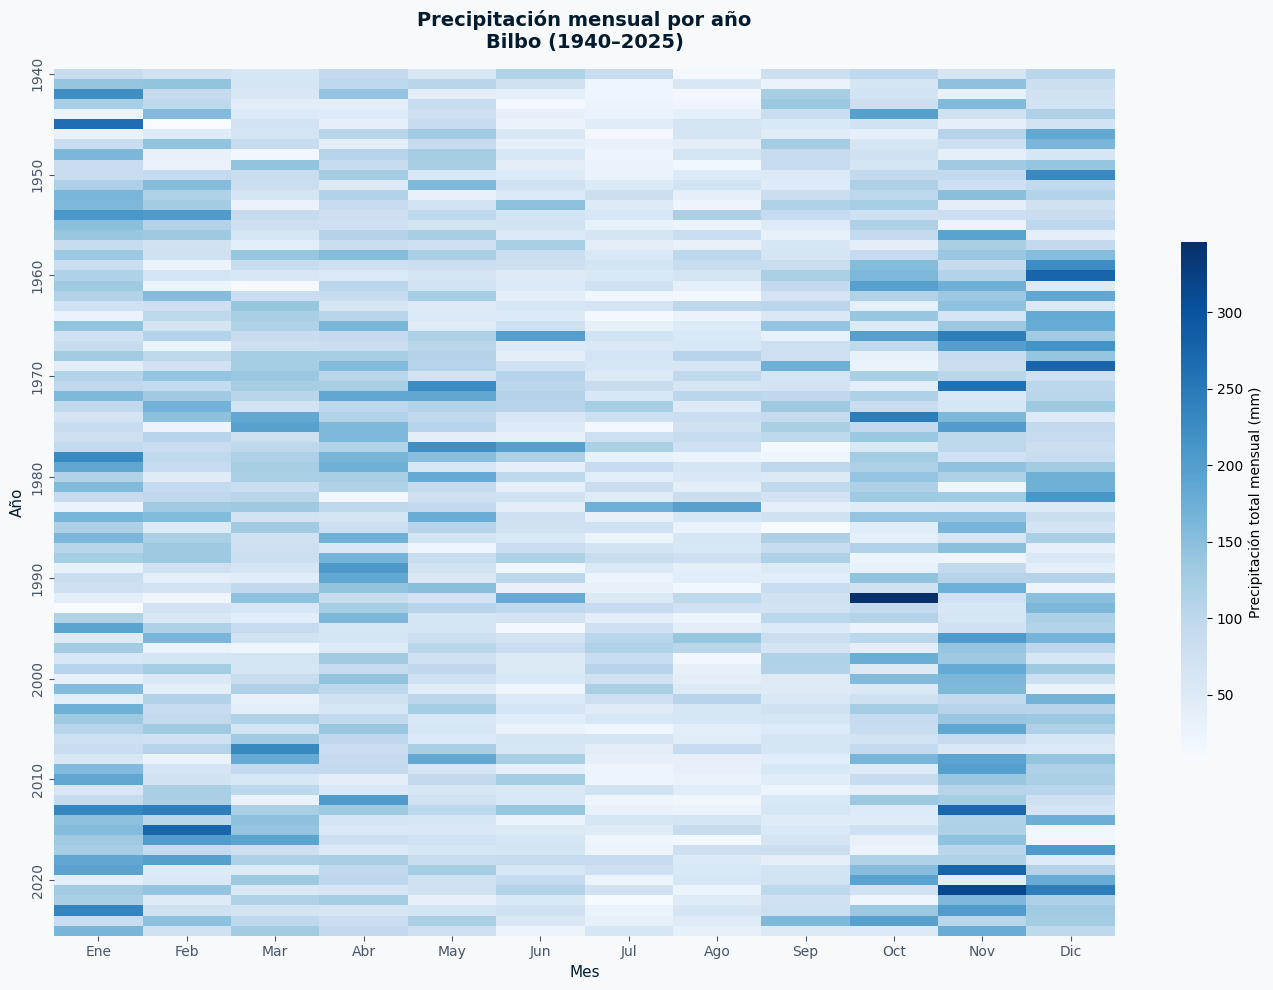

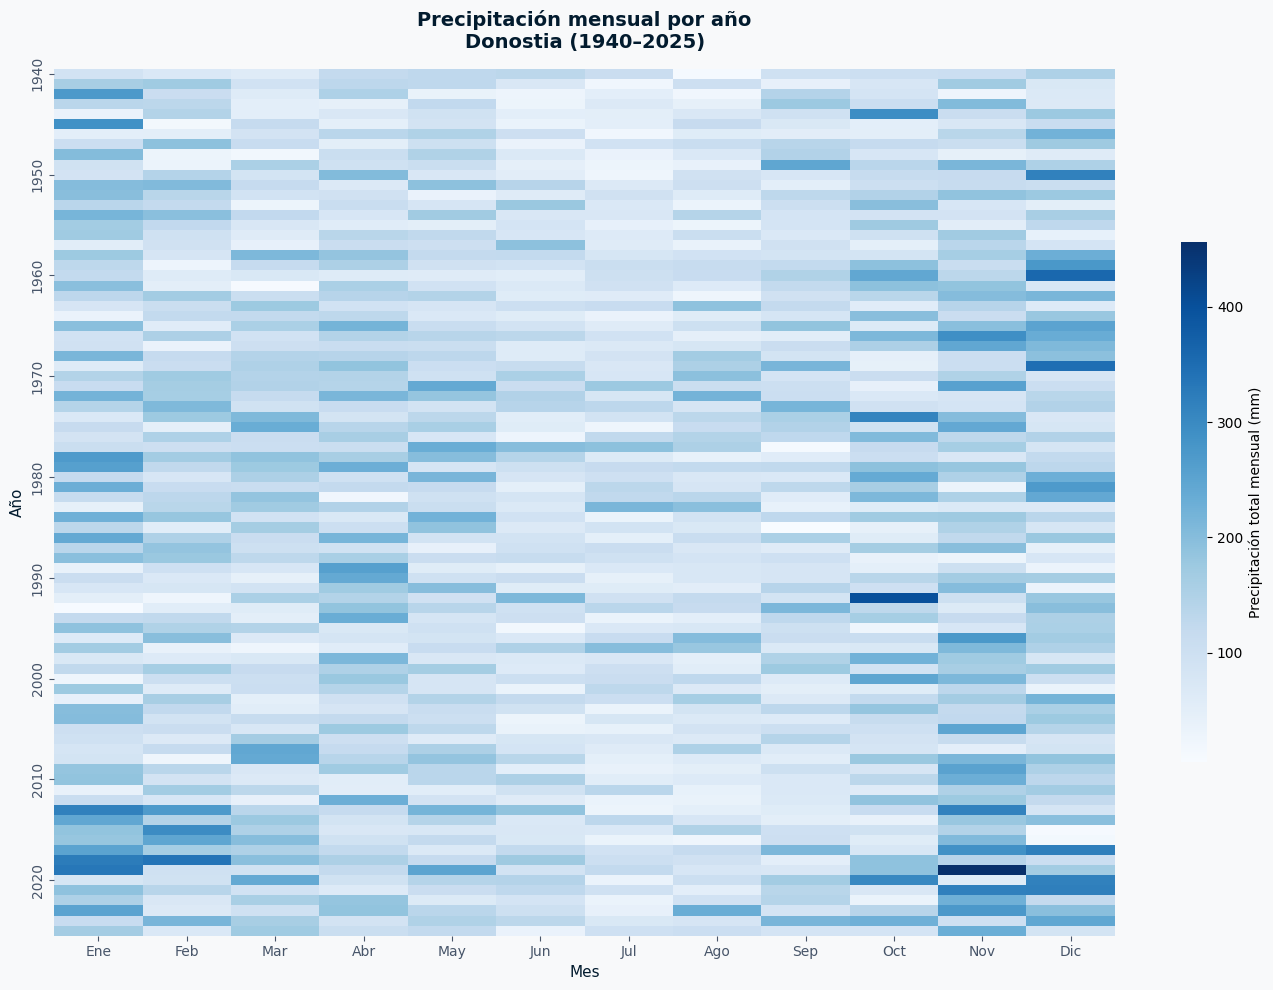

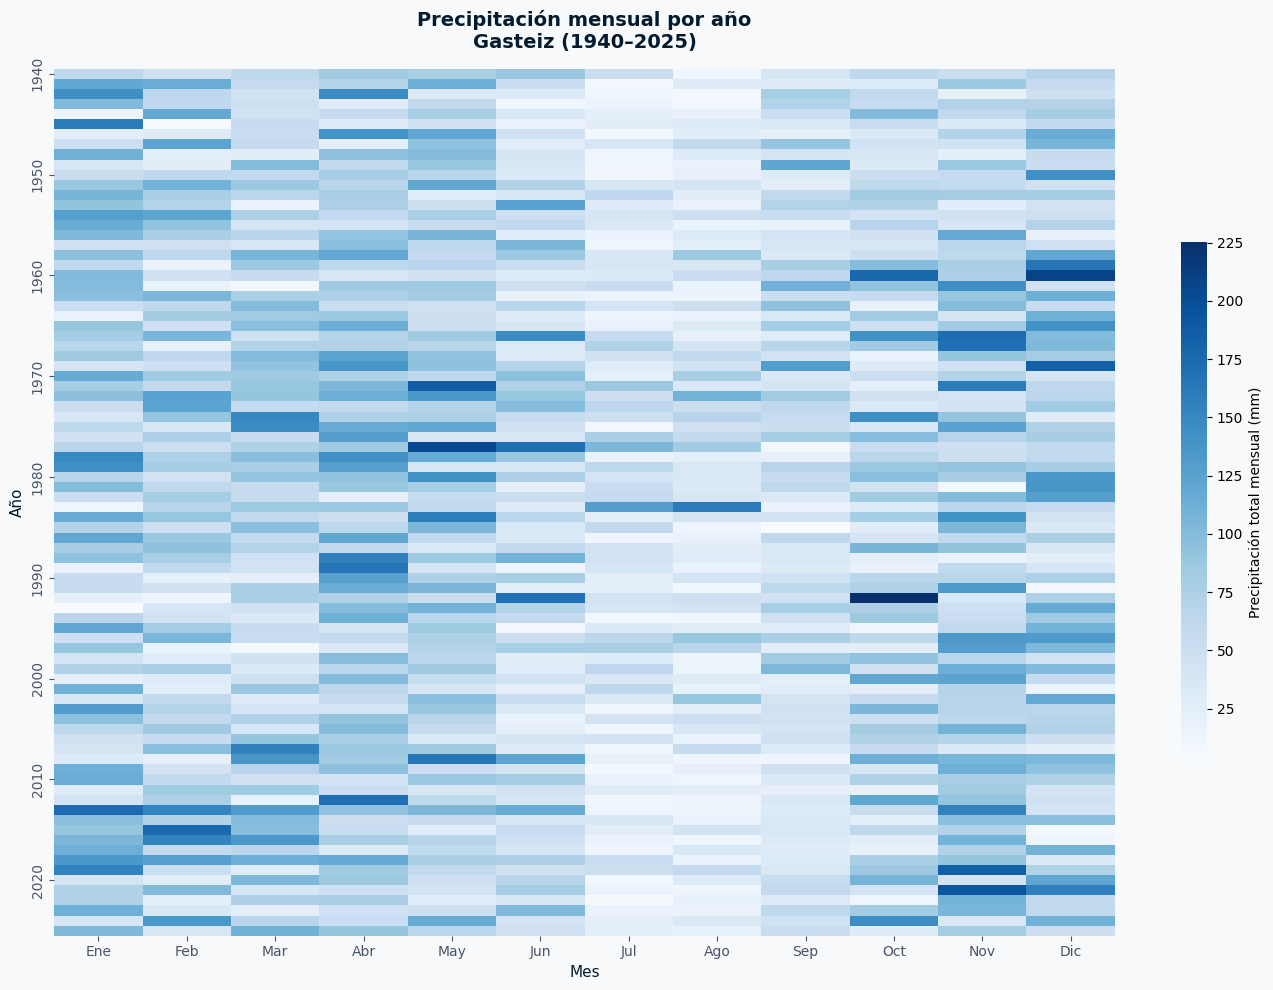

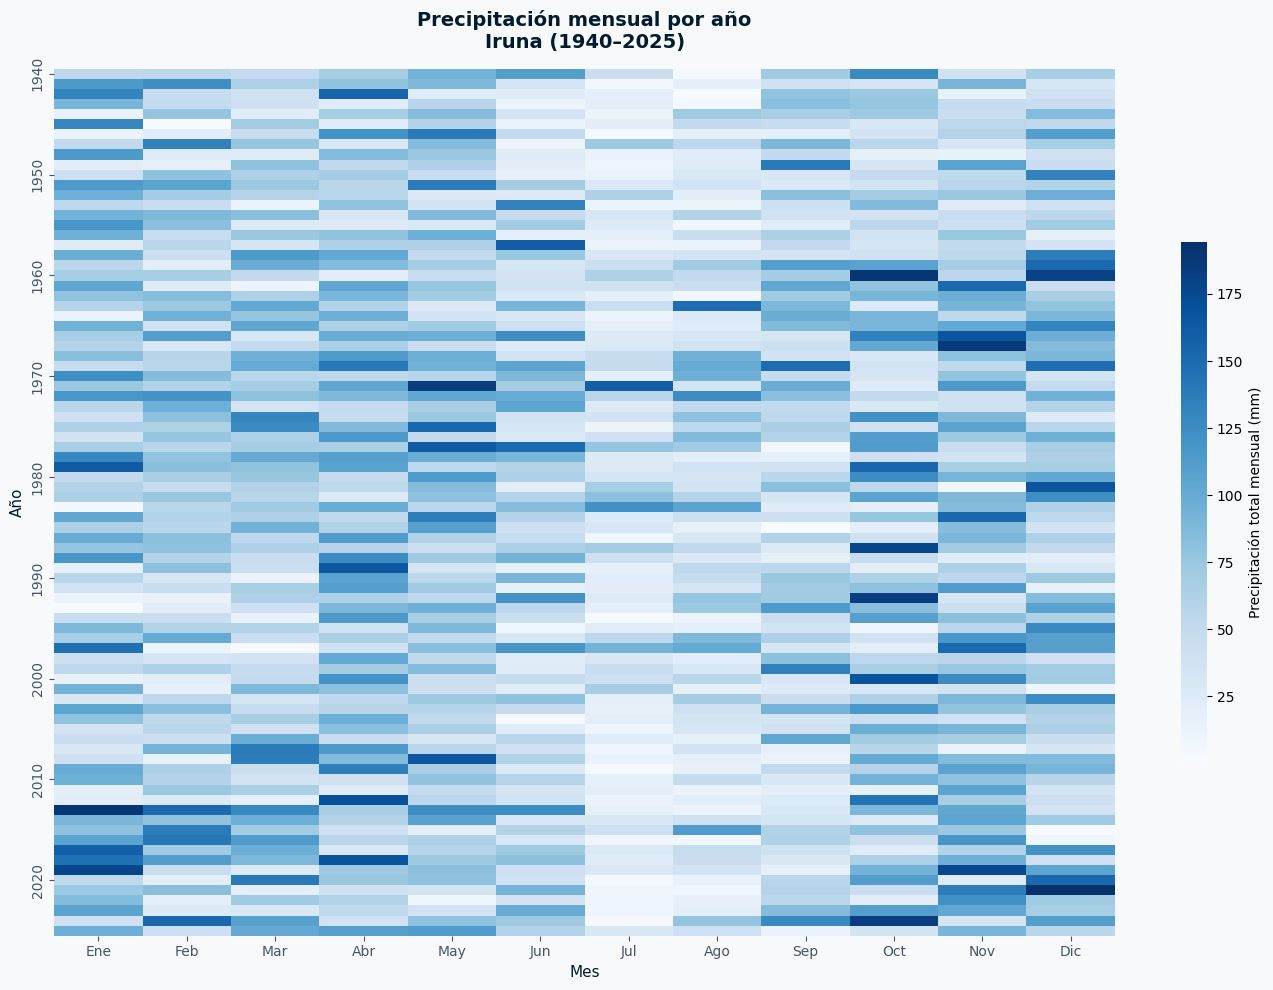

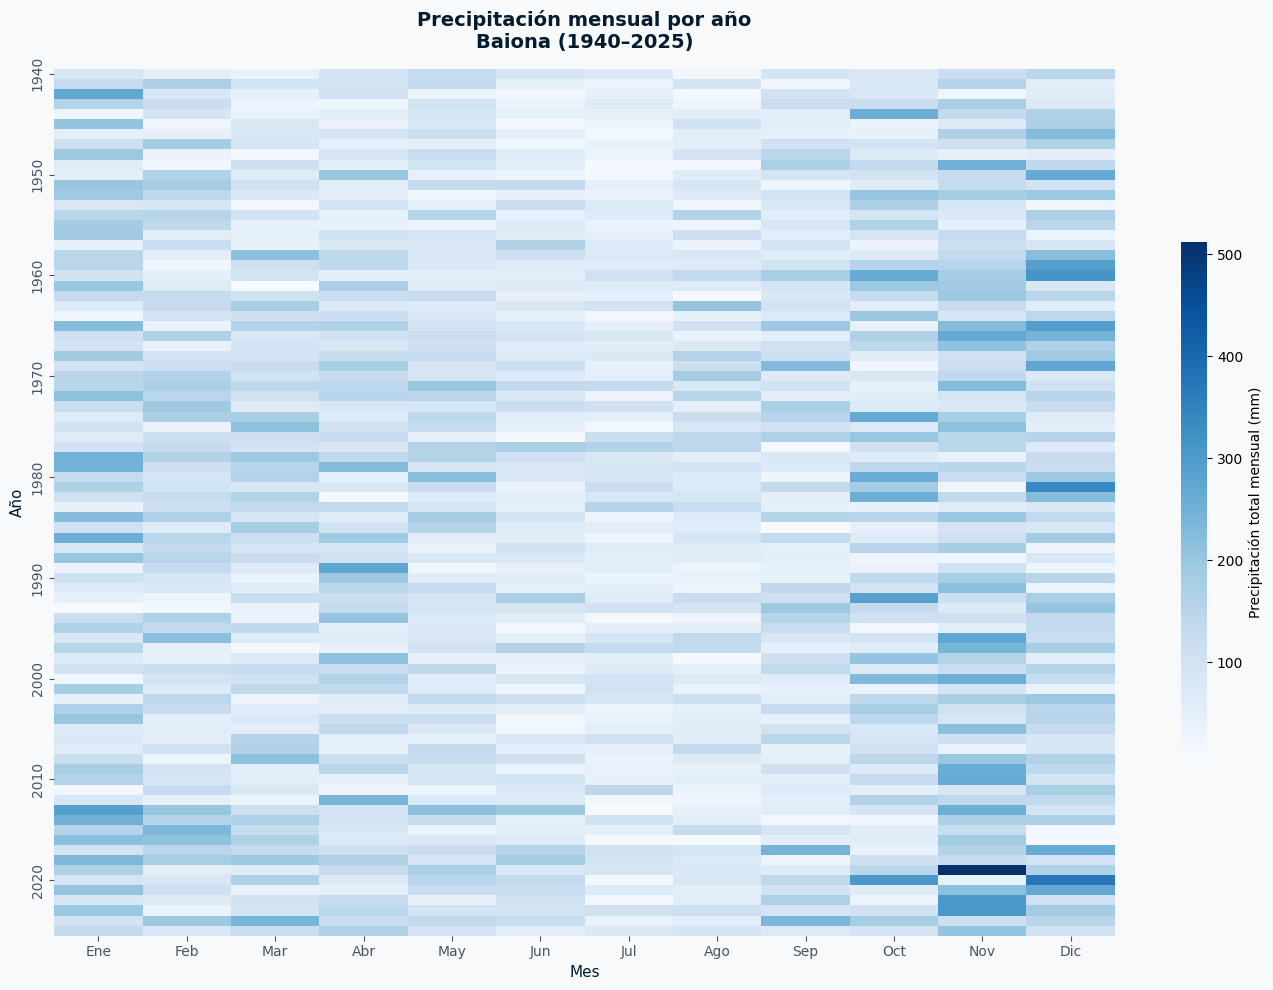

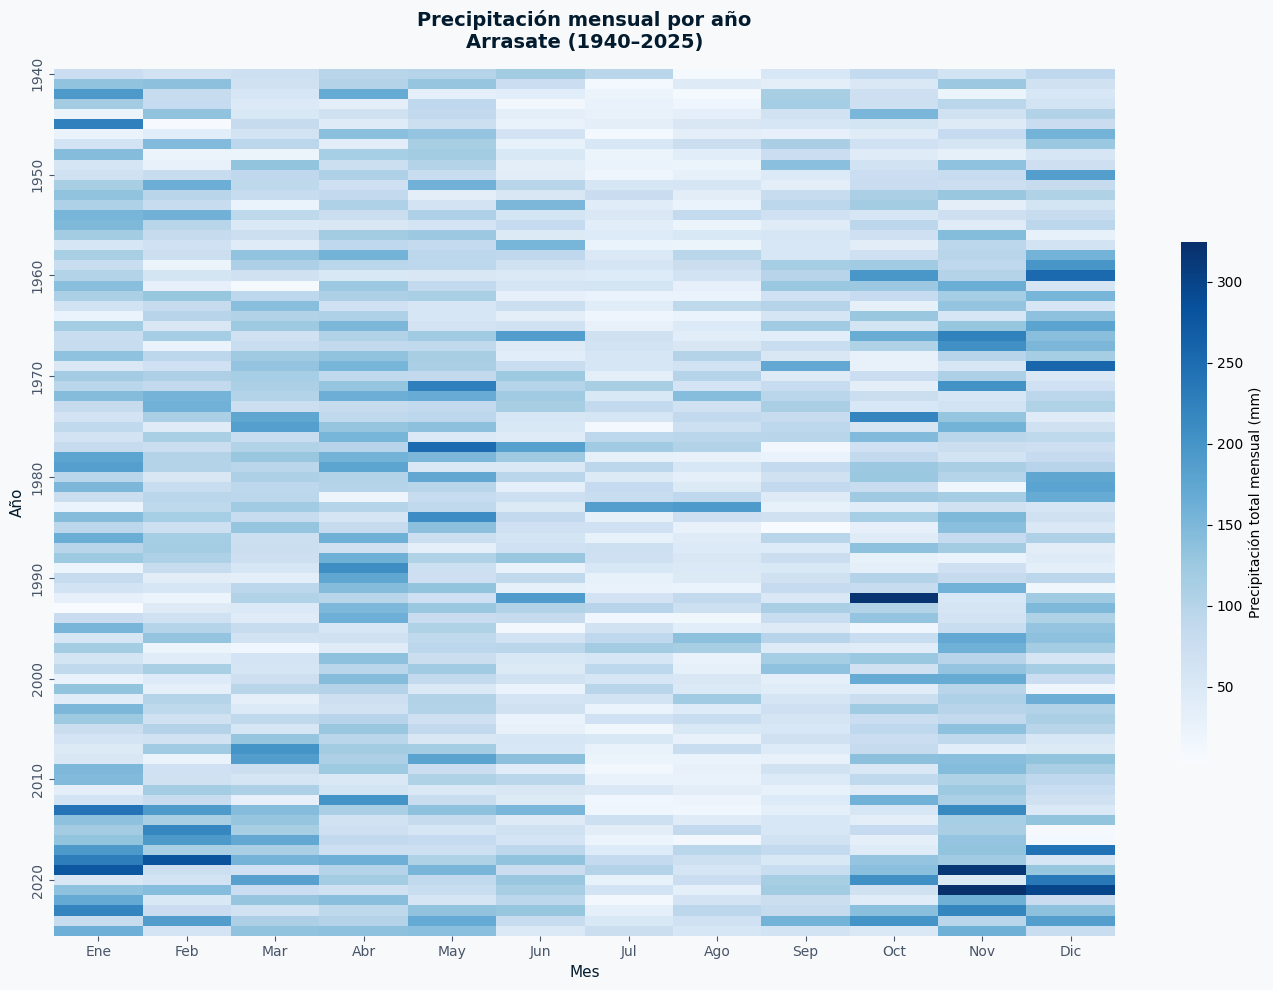

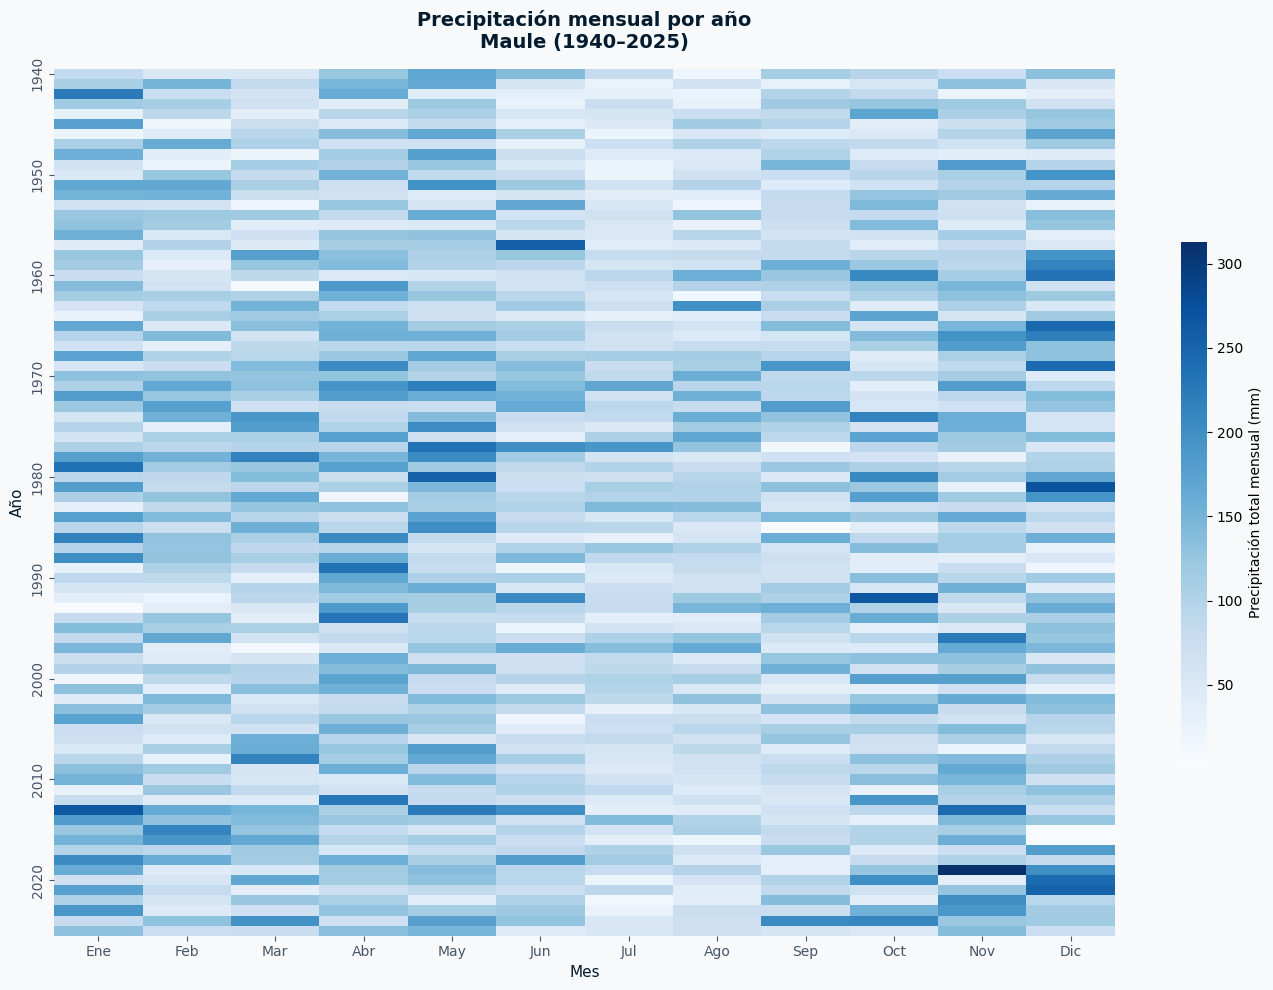

In [4]:
graficos_precip.graficar_heatmap_precip_mensual(CIUDADES)

## 5. Racha seca máxima anual

El número máximo de días consecutivos sin lluvia (< 1 mm) en cada año. Una tendencia creciente indica que, aunque el total anual no cambie mucho, el territorio pasa períodos cada vez más largos sin precipitación.

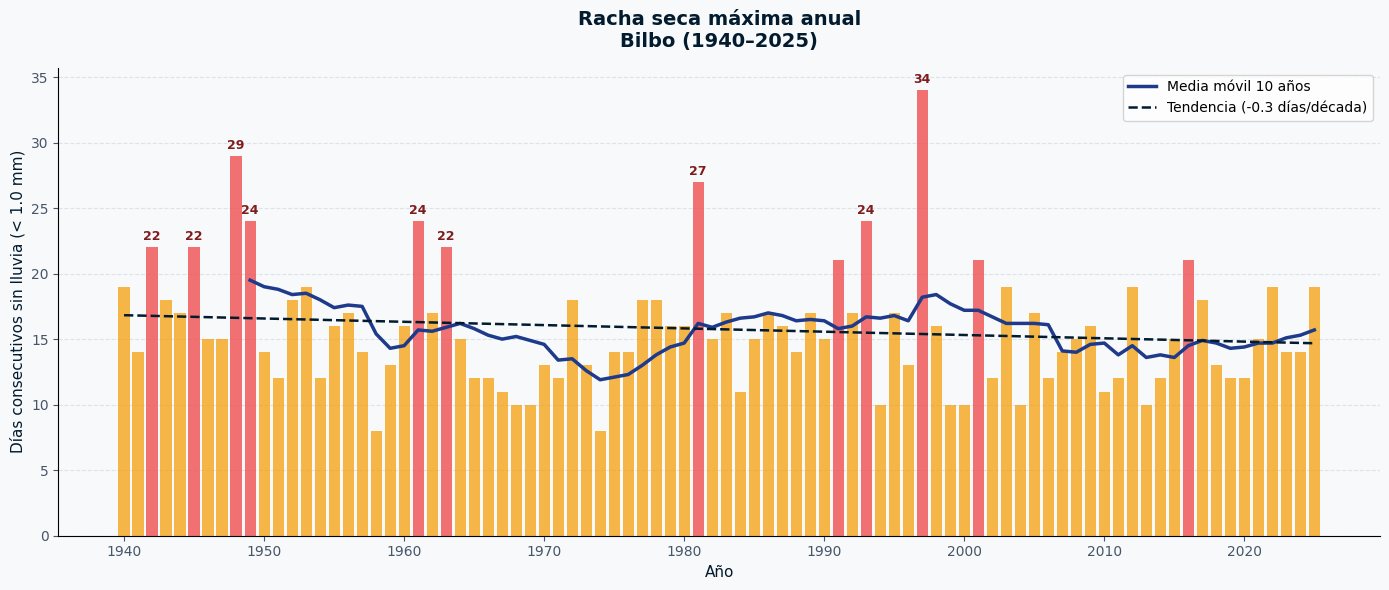

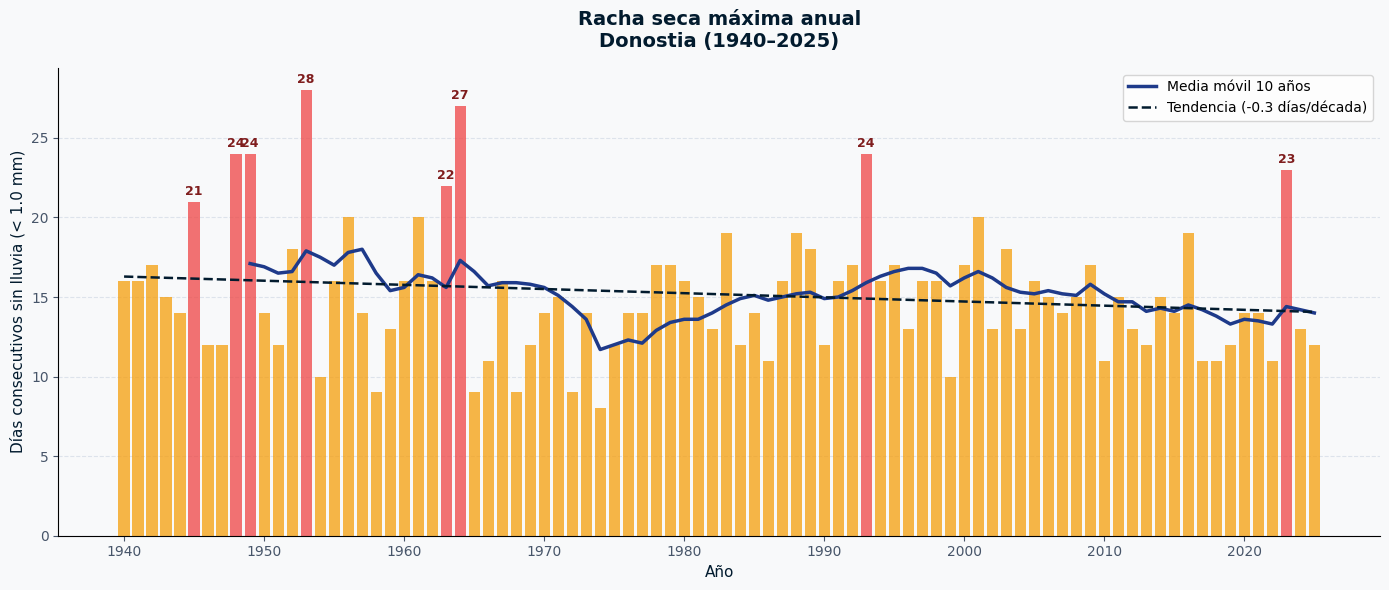

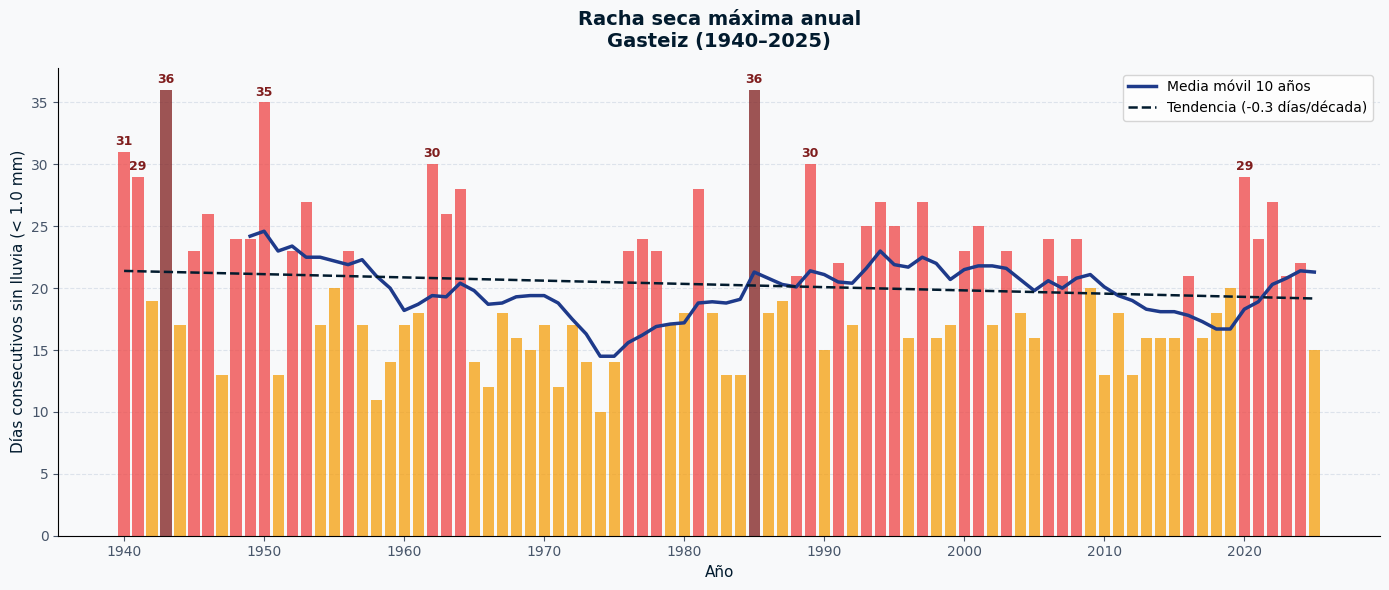

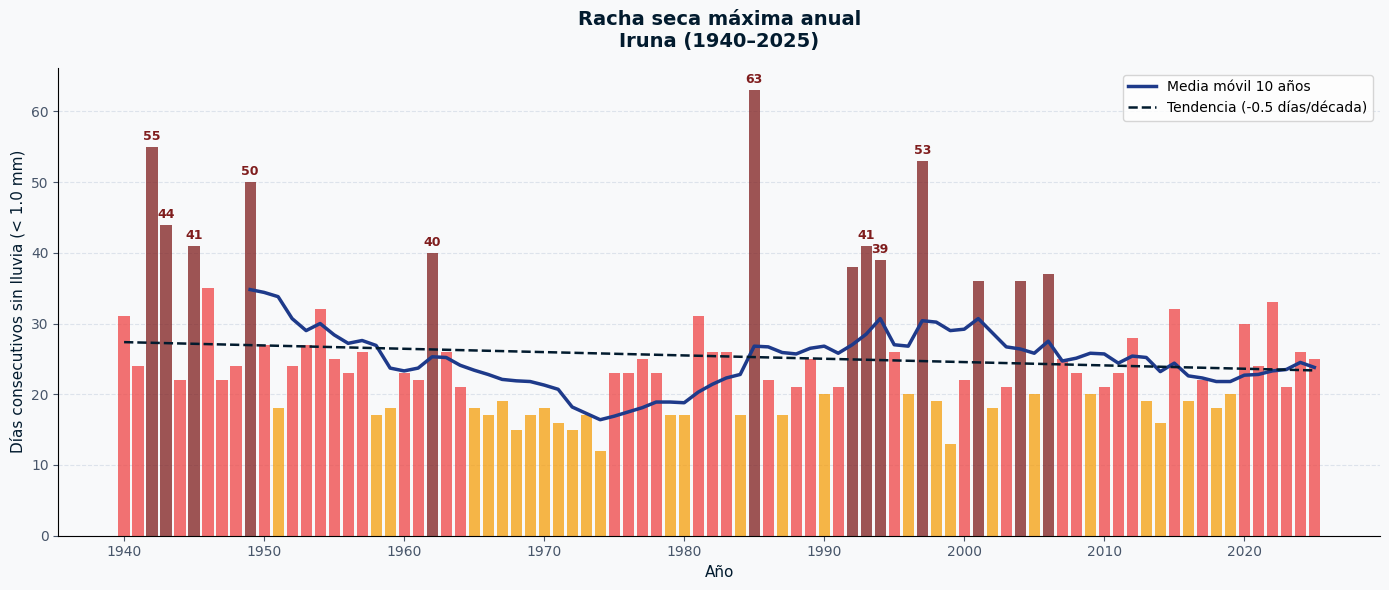

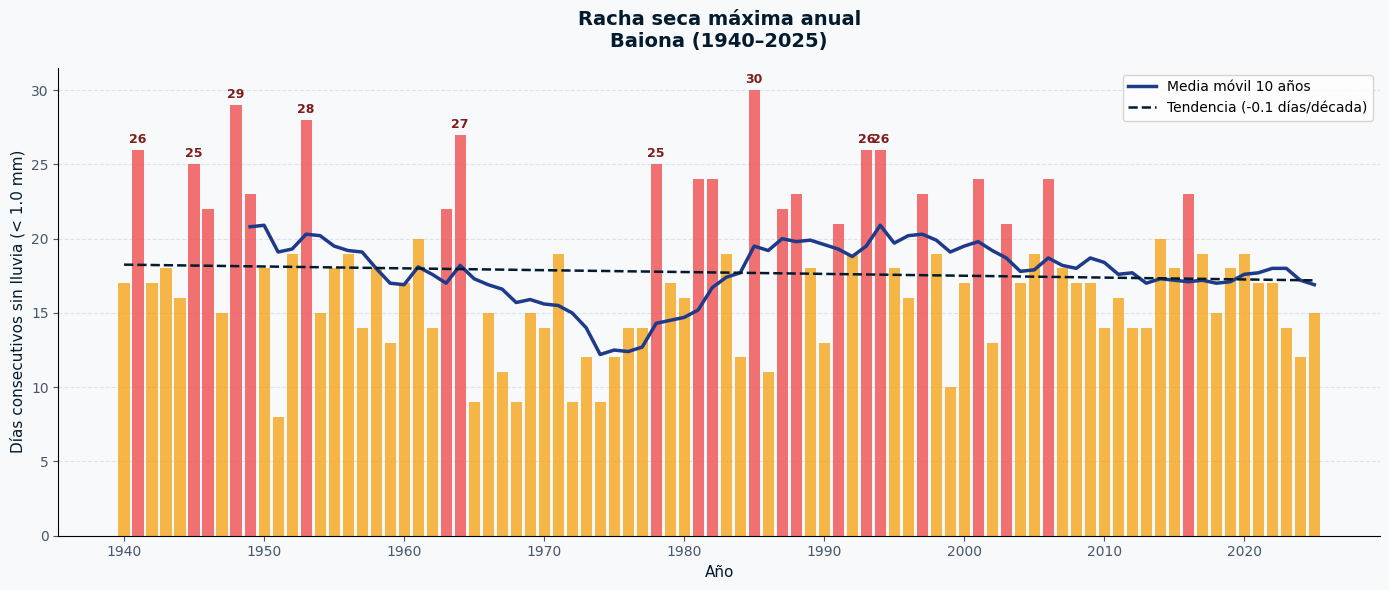

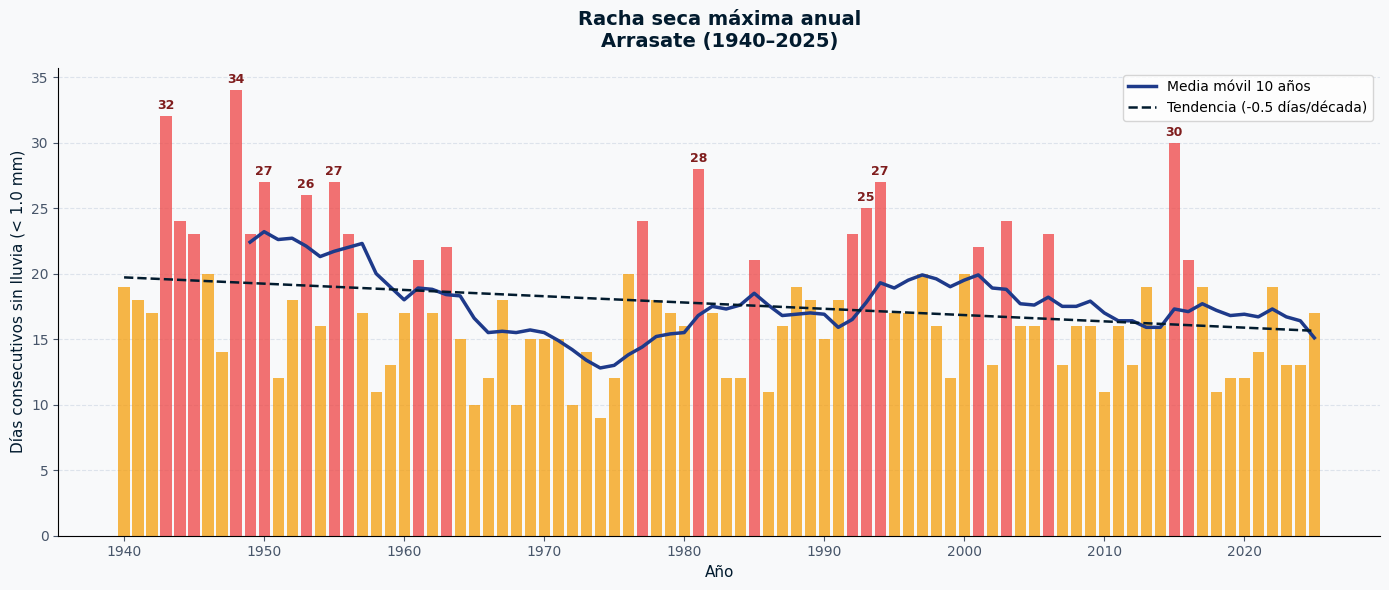

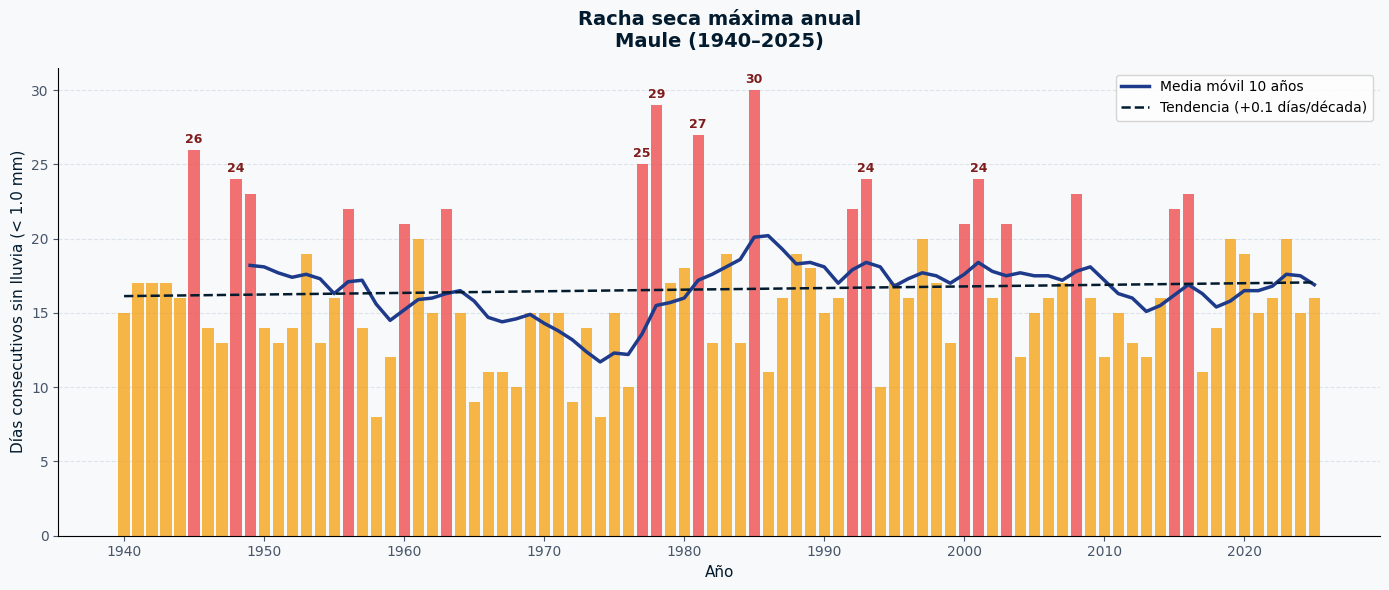

In [5]:
datos_racha = racha_seca.calcular_todos()
graficos_racha_seca.graficar_racha_seca(datos_racha)

## 6. Comparativa de racha seca entre ciudades

Superposición de medias móviles de la racha seca. Esperamos que las ciudades del interior (Gasteiz, Iruña) muestren rachas más largas que las costeras.

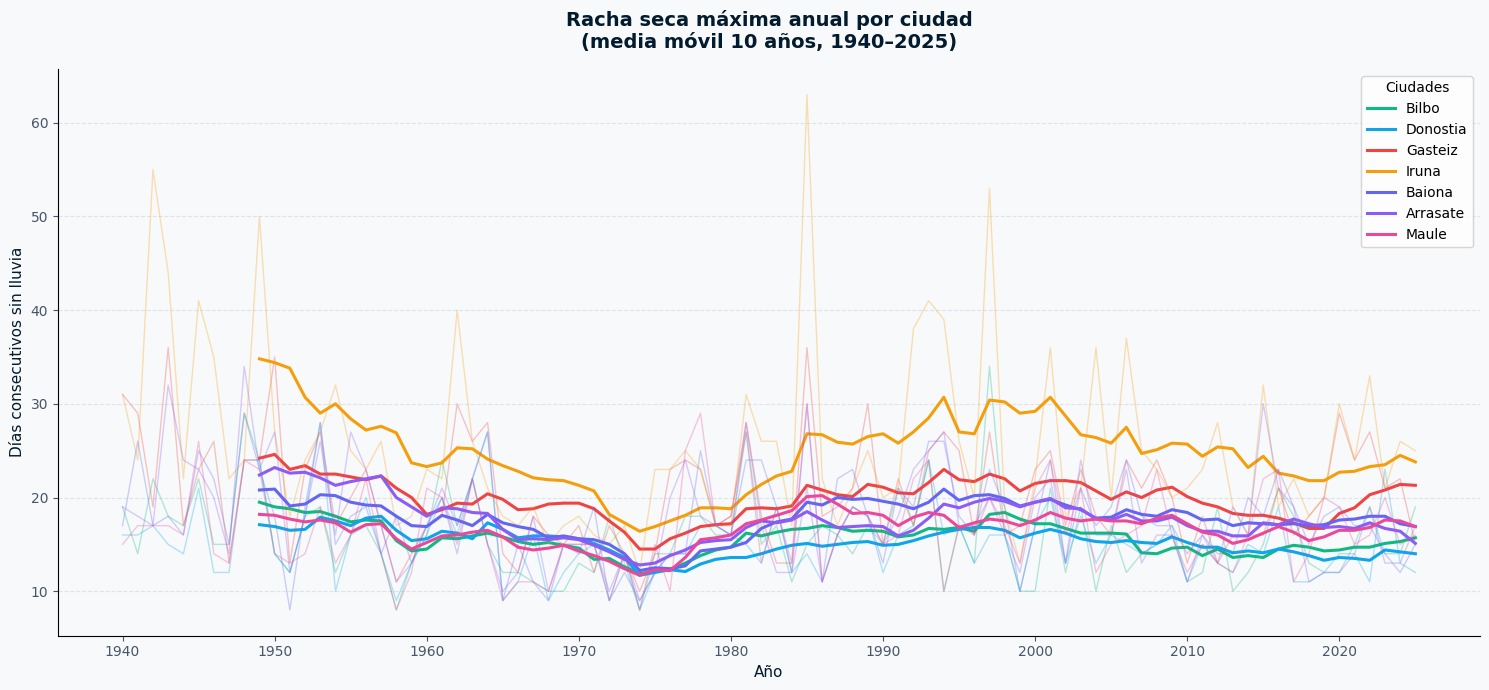

In [6]:
graficos_racha_seca.graficar_racha_comparativa(datos_racha)

## 7. Distribución de rachas secas por décadas (violinplot)

No solo cambia la media de la racha seca, sino también su distribución. Un violín más ancho hacia valores altos en décadas recientes indica que los años muy secos son más frecuentes.

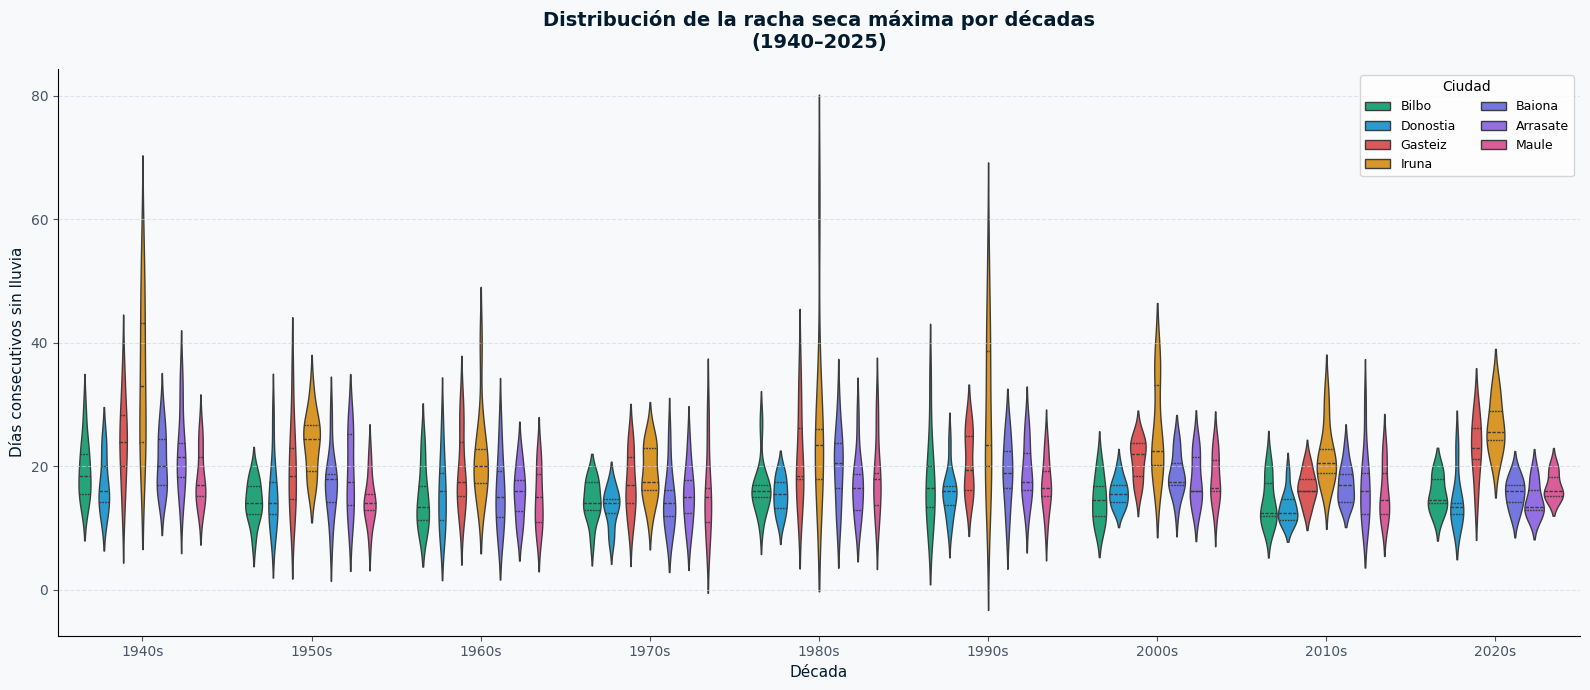

In [7]:
graficos_racha_seca.graficar_violin_rachas_decadas(CIUDADES)

## 8. Resumen estadístico

In [8]:
import pandas as pd

rows = []
for r in datos_racha:
    ciudad = r['ciudad']
    rows.append({
        'Ciudad': ciudad.nombre.capitalize(),
        'Dist. mar (km)': ciudad.dist_mar,
        'Racha media (días)': round(pd.Series(r['rachas']).mean(), 1),
        'Racha máx. histórica': int(max(r['rachas'])),
        'Tendencia (días/década)': round(r['slope'] * 10, 2),
    })

resumen = pd.DataFrame(rows).sort_values('Tendencia (días/década)', ascending=False)
display(resumen.style.background_gradient(subset=['Tendencia (días/década)'], cmap='RdYlBu_r'))

,Ciudad,Dist. mar (km),Racha media (días),Racha máx. histórica,Tendencia (días/década)
6,Maule,25.200000,16.600000,30,0.110000
4,Baiona,1.500000,17.700000,30,-0.120000
0,Bilbo,11.100000,15.800000,34,-0.250000
2,Gasteiz,58.200000,20.300000,36,-0.260000
1,Donostia,0.000000,15.200000,28,-0.260000
3,Iruna,61.800000,25.400000,63,-0.470000
5,Arrasate,33.200000,17.700000,34,-0.480000
